# 1. Introduction to Pandas


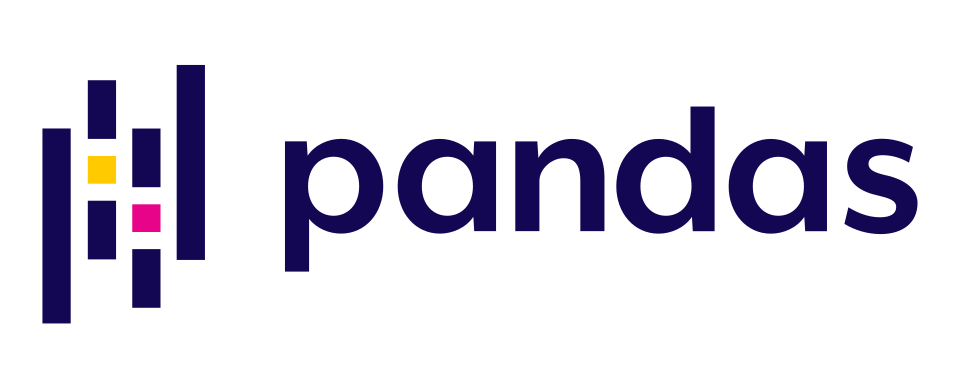

## 1.1 What is Pandas?
Pandas is an open-source Python library built for data manipulation and analysis. It provides fast, flexible, and expressive data structures designed to work with structured (tabular) and time-series data. It is built on top of NumPy.



## 1.2 Installation & Import

#### Install via conda
conda install pandas

In [4]:
import pandas as pd

# 2. Core Data Structures

## (A) Series
A Series is a one-dimensional labeled array that can hold any data type (integers, strings, floats, Python objects, etc.). Think of it as a single column in a spreadsheet.

### Creating a Series

In [5]:
series_1=pd.Series([10,20,30,40,50,60])
series_1

0    10
1    20
2    30
3    40
4    50
5    60
dtype: int64

### Series with custom index

In [6]:
series_2 = pd.Series([10, 20, 30], index=['a', 'b', 'c'])
series_2

a    10
b    20
c    30
dtype: int64

### Series from a dictionary

In [7]:
series_3 = pd.Series({'name': 'Sarthak', 'age': 20, 'city': 'Mumbai'})
series_3

name    Sarthak
age          20
city     Mumbai
dtype: object

### Accessing elements

In [8]:
# label-based
print(series_3['age']) 
print(series_2['c']) 

 # position-based
series_1[0]

20
30


np.int64(10)

## (B) DataFrame
A DataFrame is a two-dimensional labeled data structure with columns of potentially different types. Think of it as a full spreadsheet or SQL table. It is the most commonly used pandas object.

### Creating a DataFrame from a dictionary

In [9]:
df_1 = pd.DataFrame({
'name':  ['Alice', 'Bob', 'Charlie'],
'age':   [25, 30, 35],
'score': [88.5, 92.0, 78.3]
})

df_1

,name,age,score
0,Alice,25,88.5
1,Bob,30,92.0
2,Charlie,35,78.3


### From a list of dictionaries

In [10]:
data = [{'name': 'Alice', 'age': 25}, {'name': 'Bob', 'age': 30}]
df_2 = pd.DataFrame(data)
df_2

,name,age
0,Alice,25
1,Bob,30


### From a CSV file

In [12]:
order_data = pd.read_csv('orders.csv')
order_data

,order_id,product,category,price,delivered
0,1001,Phone,Electronics,15000.0,Yes
1,1002,T-Shirt,Clothing,499.0,Yes
2,1003,Laptop,Electronics,55000.0,Yes
3,1004,Rice,Grocery,120.0,Yes
4,1005,Jeans,Clothing,1200.0,No
5,1006,Earphones,Electronics,999.0,Yes
6,1007,Dress,Clothing,1899.0,Yes
7,1008,Tablet,Electronics,22000.0,No
8,1009,Sugar,Grocery,50.0,Yes
9,1010,Kurti,Clothing,799.0,Yes


### Exporting Dataframes

In [13]:
order_data.to_csv("indexed-exported-orders.csv")

When pandas saves a DataFrame to CSV, it automatically adds an extra column at the start for the row numbers (0, 1, 2, 3...), that's the index. So we write "index=False" to avoid getting the first unnamed column. So "index=False" simply means "don't write the row numbers into the file". You'll use this almost every time you export a CSV.

In [14]:
order_data.to_csv("unindexed-exported-orders.csv", index=False)

# 3. Describing Data

## (A) Attributes

### (1) dtypes
dtypes is a pandas attribute used to display the data type of each column in a DataFrame

In [16]:
order_data.dtypes

order_id       int64
product          str
category         str
price        float64
delivered        str
dtype: object

### (2) columns
.columns is a pandas attribute used to display the column names of a DataFrame

In [18]:
order_data.columns

Index(['order_id', 'product', 'category', 'price', 'delivered'], dtype='str')

### (3) index
index is a pandas attribute used to display the row labels (index values) of a DataFrame or Series.

In [20]:
order_data.index

RangeIndex(start=0, stop=15, step=1)

### (4) shape
shape is a pandas attribute used to display the dimensions of a DataFrame or Series in the form of a tuple (rows, columns).

In [21]:
order_data.shape

(15, 5)

## (B) Methods

### (1) .info()
.info() is a pandas method that displays a summary of a DataFrame.

It shows:
number of rows, column names, non-null values, data types of each column, memory usage

In [28]:
order_data.info()  

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   order_id   15 non-null     int64  
 1   product    15 non-null     str    
 2   category   15 non-null     str    
 3   price      14 non-null     float64
 4   delivered  15 non-null     str    
dtypes: float64(1), int64(1), str(3)
memory usage: 732.0 bytes


### (2) .describe()
.describe() is a pandas method used to generate statistical summary statistics of numerical columns in a DataFrame or Series

It typically shows:
count (number of values), mean (average), std (standard deviation), min (minimum value), 25%, 50%, 75% (quartiles), max (maximum value)

In [29]:
order_data.describe()

,order_id,price
count,15.000000,14.000000
mean,1008.000000,7954.714286
std,4.472136,15194.534931
min,1001.000000,50.000000
25%,1004.500000,259.750000
50%,1008.000000,1099.500000
75%,1011.500000,9474.750000
max,1015.000000,55000.000000


### NOTE: describe works on only numeric columns and here, the amount is an object( look at dtypes ) 


### (3) .mean()
mean() is a pandas method used to calculate the average (arithmetic mean) of numeric values in a dataframe or series.


In [37]:
order_data["price"].mean()

np.float64(7954.714285714285)

You can also compute mean directly on a standalone Series

In [42]:
order_values = pd.Series([250, 400, 1500])
order_values.mean()

np.float64(716.6666666666666)

### (4) .sum()
sum() is a pandas method used to calculate the total sum of values in a DataFrame or Series

In [44]:
order_data["price"].sum()

np.float64(111366.0)

In [45]:
order_data.sum()

order_id                                                 15120
product      PhoneT-ShirtLaptopRiceJeansEarphonesDressTable...
category     ElectronicsClothingElectronicsGroceryClothingE...
price                                                 111366.0
delivered           YesYesYesYesNoYesYesNoYesYesYesYesYesNoYes
dtype: object

It adds all numeric values in the dataset (column wise if it’s a DataFrame)

## 4. Viewing & Selecting Data

### (1) .head()
.head() displays the first 5 rows of a pandas DataFrame or Series to quickly preview the data

In [31]:
order_data.head()

,order_id,product,category,price,delivered
0,1001,Phone,Electronics,15000.0,Yes
1,1002,T-Shirt,Clothing,499.0,Yes
2,1003,Laptop,Electronics,55000.0,Yes
3,1004,Rice,Grocery,120.0,Yes
4,1005,Jeans,Clothing,1200.0,No


If you want to view a specific number of rows, you can add the number inside the parentheses of .head(), and it will display that many rows

In [32]:
order_data.head(8)

,order_id,product,category,price,delivered
0,1001,Phone,Electronics,15000.0,Yes
1,1002,T-Shirt,Clothing,499.0,Yes
2,1003,Laptop,Electronics,55000.0,Yes
3,1004,Rice,Grocery,120.0,Yes
4,1005,Jeans,Clothing,1200.0,No
5,1006,Earphones,Electronics,999.0,Yes
6,1007,Dress,Clothing,1899.0,Yes
7,1008,Tablet,Electronics,22000.0,No


### (2) .tail()
.tail() displays the last 5 rows of a pandas DataFrame or Series to quickly view the end of the data

In [33]:
order_data.tail()

,order_id,product,category,price,delivered
10,1011,Phone,Electronics,12000.0,Yes
11,1012,Oil,Grocery,180.0,Yes
12,1013,Laptop,Electronics,NaN,Yes
13,1014,Jeans,Clothing,1500.0,No
14,1015,Rice,Grocery,120.0,Yes


Similar to .head(), if you want a specific number of rows, you can add the number inside the parentheses

In [34]:
order_data.tail(7)

,order_id,product,category,price,delivered
8,1009,Sugar,Grocery,50.0,Yes
9,1010,Kurti,Clothing,799.0,Yes
10,1011,Phone,Electronics,12000.0,Yes
11,1012,Oil,Grocery,180.0,Yes
12,1013,Laptop,Electronics,NaN,Yes
13,1014,Jeans,Clothing,1500.0,No
14,1015,Rice,Grocery,120.0,Yes


# 5. Length Function
len() is used to find the number of rows (length) in a DataFrame or Series

In [48]:
print(len(order_data))

15


# 6. Manipulating Data

### (3) .loc[]
.loc[] is a pandas indexer used to select rows and columns by label (index value). It uses the actual index labels, not positions.

In [ ]:
animals = pd.Series(
    ["cat", "dog", "lion", "tiger", "pandas"],
    index=[0, 3, 9, 8, 3])
animals

In [ ]:
# Select by label — returns all entries with that index label
animals.loc[3]

In [ ]:
animals.loc[9]

You can also use .loc[] on a DataFrame to select a row by its index label

In [ ]:
order_data.loc[3]

### (4) .iloc[]
.iloc[] is a pandas indexer used to select rows and columns by integer position (0-based). It always works on position, regardless of what the index labels are.

In [ ]:
# Select by position
animals.iloc[3]

In [ ]:
order_data.iloc[3]

You can also use .iloc[] to slice a range of rows by position

In [ ]:
# First 3 rows by position
animals.iloc[:3]

In [ ]:
order_data.iloc[:3]

### NOTE: .loc[] uses labels, .iloc[] uses positions. They can return different results if the index is not the default 0, 1, 2...

### (5) Column Selection
You can select a single column from a DataFrame using bracket notation or dot notation. Both return a Series.

In [ ]:
# Bracket notation — works for all column names
order_data["product"]

Dot notation is a shortcut, but only works when the column name has no spaces or special characters

In [ ]:
# Dot notation
order_data.product

### (6) Boolean Filtering
Boolean filtering lets you select rows that match a condition. You pass a condition inside square brackets and pandas returns only the rows where that condition is True.

In [ ]:
# Single condition
order_data[order_data["quantity"] > 2]

You can combine multiple conditions using & (and) or | (or). Each condition must be wrapped in parentheses.

In [ ]:
# Multiple conditions
order_data[
    (order_data["quantity"] > 1) &
    (order_data["price"] > 10)
]

### (7) pd.crosstab()
pd.crosstab() is a pandas function used to compute a frequency table showing how often combinations of two categorical variables occur together.

In [ ]:
pd.crosstab(order_data["product"], order_data["quantity"])

### (8) .groupby()
.groupby() is a pandas method used to group rows that share the same value in a column, and then apply an aggregation function (like .mean(), .sum(), .count()) to each group.

In [ ]:
order_data.groupby("product").mean(numeric_only=True)

You can also chain filtering with .groupby() to aggregate on a specific subset of data

In [ ]:
order_data[
    order_data["quantity"] > 1
].groupby("product").mean(numeric_only=True)

# 5. Plotting
Pandas has built-in plotting support through matplotlib. You can quickly visualize a column using .plot() or .hist() directly on a Series or DataFrame.

## (A) Line Plot
.plot() generates a line plot by default. It is useful for visualizing how values change across rows or over time.

In [ ]:
order_data["price"].plot()

## (B) Histogram
.hist() generates a histogram, which shows the frequency distribution of values in a column.

In [ ]:
order_data["price"].hist()

### NOTE: If a column has the wrong dtype (e.g. price stored as a string like "$10.00"), the plot will fail. Fix the dtype first before plotting.

# 6. Data Types
Every column in a pandas DataFrame has a dtype (data type). Pandas cannot perform numeric operations like .mean() or .plot() on columns stored as object (string). You need to convert them first.

## (A) Checking a column's dtype
Use .dtype on a single column to check what type it is stored as.

In [ ]:
order_data["price"].dtype

## (B) Converting dtype
If a numeric column is stored as a string (e.g. it contains "$" or ","), you need to strip those characters first using .str.replace(), then convert using .astype().

In [ ]:
order_data["price"] = (
    order_data["price"]
    .str.replace(r"[$,]", "", regex=True)
    .astype(float)
)
order_data

Now that the column is numeric, you can plot it properly

In [ ]:
order_data["price"].plot()

# 7. Manipulating Data

## (A) String Operations
.str accessor lets you apply string methods to an entire column at once. It operates element-wise on every value in the Series.

### .str.lower()
.str.lower() is a pandas string method used to convert all characters in a string column to lowercase.

In [ ]:
order_data["product"].str.lower()

To make the change permanent, assign it back to the column

In [ ]:
order_data["product"] = order_data["product"].str.lower()
order_data

## (B) Missing Data
Pandas describes missing data as "NaN" (NaN stands for Not a Number)

### .fillna()
.fillna() is a pandas method used to fill missing (NaN) values in a DataFrame or Series with a specified value or strategy.

In [ ]:
order_data_missing = pd.read_csv("orders-missing-data.csv")
order_data_missing

A common strategy is to fill missing values with the mean of the column, so the overall average is not affected

In [ ]:
order_data_missing["price"].fillna(order_data_missing["price"].mean())

Use inplace=True to apply the change directly to the DataFrame without reassigning

In [ ]:
order_data_missing["price"].fillna(order_data_missing["price"].mean(), inplace=True)
order_data_missing

## (C) Adding Columns
You can add new columns to a DataFrame in several ways depending on where the data comes from.

### From a Series
You can create a new column by assigning a Series to a new column name. Pandas will align values by index.

In [ ]:
# Column from a Series
quantity_column = pd.Series([1, 2, 3, 4, 5])

order_data["quantity_copy"] = quantity_column
order_data

If there are missing values after assigning from a Series (due to index misalignment), fill them using .fillna()

In [ ]:
order_data["quantity_copy"].fillna(1, inplace=True)
order_data

### From a Python List
You can also create a new column by directly assigning a Python list. The list must be the same length as the DataFrame.

In [ ]:
# Column from a Python List
discount = [0.1, 0.2, 0.0, 0.15, 0.05]
order_data["discount"] = discount
order_data

### From another column
You can derive a new column by performing arithmetic operations on existing columns.

In [ ]:
# Column from another column
order_data["discounted_price"] = order_data["price"] - (order_data["price"] * order_data["discount"])
order_data

### From a single value
Assigning a single scalar value creates a column where every row has that same value.

In [ ]:
# Create a column from a single value
order_data["currency"] = "USD"
order_data

This also works with boolean values

In [ ]:
order_data["is_active"] = True
order_data

## (D) Removing Columns
.drop() is a pandas method used to remove rows or columns from a DataFrame.

Use axis=1 to drop a column, and axis=0 to drop a row.

In [ ]:
# Removing a column
order_data = order_data.drop("quantity_copy", axis=1)
order_data

## (E) Sampling
.sample() is a pandas method used to randomly select a subset of rows from a DataFrame or Series.

### Shuffling all rows
Passing frac=1 returns all rows in a random order, effectively shuffling the DataFrame.

In [ ]:
order_data_shuffled = order_data.sample(frac=1)
order_data_shuffled

### Selecting a fraction of the data
You can use .sample() to select a random percentage of rows. For example, frac=0.2 returns 20% of the rows.

In [ ]:
# Only selecting 20% of the data
order_data_shuffled.sample(frac=0.2)

## (F) Resetting the Index
.reset_index() is a pandas method used to reset the index of a DataFrame back to the default integer index (0, 1, 2, ...).

Use drop=True to avoid adding the old index as a column, and inplace=True to apply it directly.

In [ ]:
order_data_shuffled.reset_index(drop=True, inplace=True)
order_data_shuffled

## (G) Applying Functions
.apply() is a pandas method used to apply a function along an axis of a DataFrame or on a Series element-by-element.

It is commonly used with lambda functions for quick, inline transformations.

In [ ]:
# Convert price from USD to INR
order_data["price_inr"] = order_data["price"].apply(lambda x: x * 83)
order_data